In [84]:
#Imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
import ast
from scipy import stats


In [85]:
tweets = pd.read_csv('Cleaned_Tweets_Data.csv')

In [86]:
tweets["Hashtags_parsed"] = tweets['Hashtags'].dropna().apply(ast.literal_eval)

In [87]:
exp = tweets.dropna(subset=['Hashtags']).copy()
exp['Hashtags_parsed'] = exp['Hashtags'].apply(ast.literal_eval)
exp = exp.explode('Hashtags_parsed')

In [88]:
# Drop index column if present (from older CSV exports without index=False)
if 'Unnamed: 0' in tweets.columns:
    tweets = tweets.drop(columns='Unnamed: 0')
tweets.head()


,Id,Media,Likes,Retweets,Date,Text,Hashtags,Hashtags_parsed
0,2090076316716736674,https://pbs.twimg.com/media/HQD67gcX0AAh6U2.jpg,4,4,2026-08-19 14:00:00+00:00,Ego,NaN,NaN
1,2089896522292834366,https://pbs.twimg.com/media/HQDNwq3WYAE7j6U.jpg,5,1,2026-08-19 02:05:33+00:00,Perugius Sketch from memory,NaN,NaN
2,2085391698402955589,https://pbs.twimg.com/media/HPAaZFvWUAAsjBw.jpg,1,1,2026-08-06 15:45:00+00:00,Sketch,NaN,NaN
3,2085192279082320247,https://pbs.twimg.com/media/HPAXN2FXYAAiFaK.jpg,5,4,2026-08-06 02:32:34+00:00,Recent Character design I did for fun,NaN,NaN
4,2083635519108403559,https://pbs.twimg.com/media/HOqPb_pXAAAX5GR.jpg,1,3,2026-08-01 19:26:34+00:00,Arthur,NaN,NaN


In [89]:
#Compute basic statistics
tweets.select_dtypes(['int','float']).describe()

,Id,Likes,Retweets
count,5.730000e+02,573.000000,573.000000
mean,1.622365e+18,48.811518,8.572426
std,2.451278e+17,173.581371,30.848327
min,1.072685e+18,0.000000,0.000000
25%,1.415528e+18,6.000000,0.000000
50%,1.622443e+18,12.000000,2.000000
75%,1.827811e+18,26.000000,6.000000
max,2.090076e+18,2153.000000,522.000000


In [90]:
tweets.select_dtypes(['object']).describe()

,Media,Date,Text,Hashtags,Hashtags_parsed
count,573,573,469,51,51
unique,573,573,448,44,44
top,https://pbs.twimg.com/media/HQD67gcX0AAh6U2.jpg,2026-08-19 14:00:00+00:00,Practice,['PortfolioDay'],[PortfolioDay]
freq,1,1,7,3,3


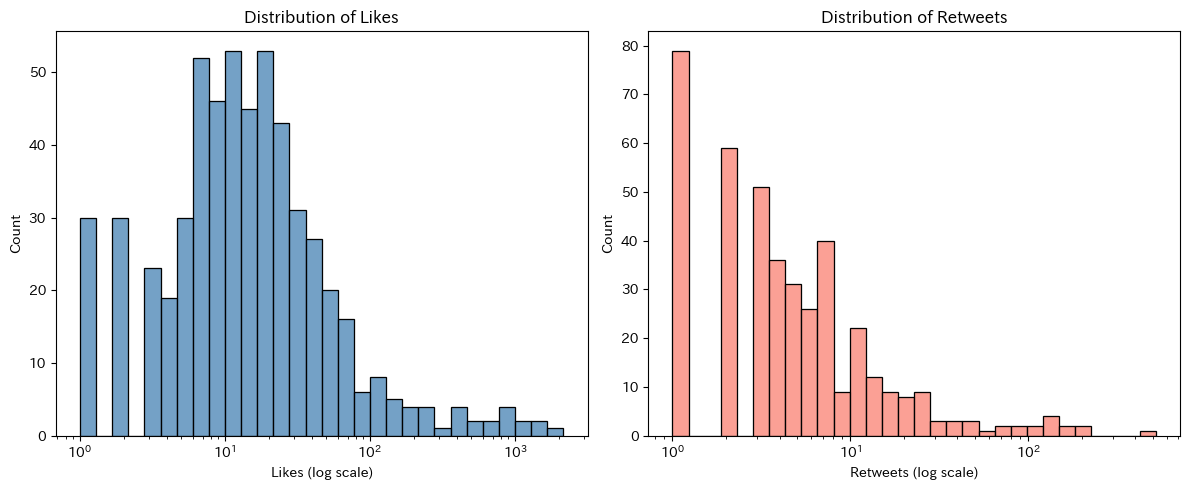

In [105]:
# Distribution of Likes and Retweets
#Log-based bins b/c of skew-ness (0s)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(tweets['Likes'], bins=30, log_scale=True, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Likes (log scale)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Likes')

sns.histplot(tweets['Retweets'], bins=30, log_scale=True, ax=axes[1], color='salmon')
axes[1].set_xlabel('Retweets (log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Retweets')

plt.tight_layout()
plt.show()


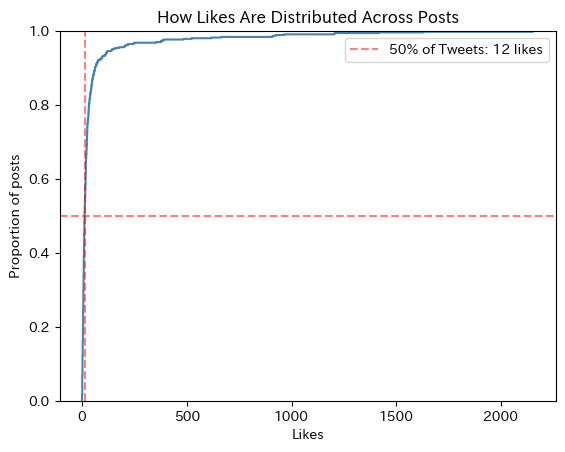

In [92]:
median_likes = int(tweets['Likes'].median())
p90_likes = int(tweets['Likes'].quantile(0.9))

sns.ecdfplot(tweets['Likes'], color='steelblue')

plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(median_likes, color='red', linestyle='--', alpha=0.5,
            label=f'50% of Tweets: {median_likes} likes')

plt.xlabel('Likes')
plt.ylabel('Proportion of posts')
plt.title('How Likes Are Distributed Across Posts')
plt.legend()
plt.show()

In [93]:
hashtag_totals = (
    exp.groupby('Hashtags_parsed')['Likes']
    .sum()
    .sort_values(ascending=True)
)

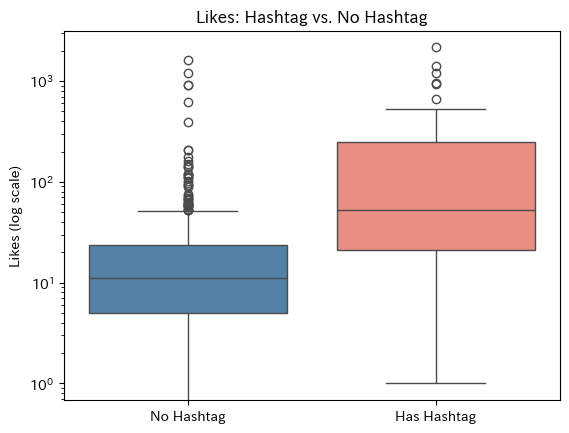

has_hashtag
False    11.0
True     52.0
Name: Likes, dtype: float64


In [94]:
#Relationship between Hashtags and Likes
tweets['has_hashtag'] = tweets['Hashtags'].notna()

sns.boxplot(data=tweets, x='has_hashtag', y='Likes',
            hue='has_hashtag', legend=False, palette=['steelblue', 'salmon'])
plt.yscale('log')
plt.xticks([0, 1], ['No Hashtag', 'Has Hashtag'])
plt.xlabel('')
plt.ylabel('Likes (log scale)')
plt.title('Likes: Hashtag vs. No Hashtag')
plt.show()

print(tweets.groupby('has_hashtag')['Likes'].median())




In [95]:
#Mann Whitney (Good B/c its not using a normal distribution)
with_tag    = tweets[tweets['has_hashtag'] == True]['Likes']
without_tag = tweets[tweets['has_hashtag'] == False]['Likes']

stat, p = stats.mannwhitneyu(with_tag, without_tag, alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"p-value: {p:.4f}")
print()
if p < 0.05:
    print("Result: statistically significant difference (p < 0.05).")
    print("Posts with hashtags have a meaningfully different like count than those without.")
else:
    print("Result: no statistically significant difference (p >= 0.05).")
    print("Cannot conclude that hashtags affect likes based on this data.")

Mann-Whitney U statistic: 21400.5
p-value: 0.0000

Result: statistically significant difference (p < 0.05).
Posts with hashtags have a meaningfully different like count than those without.


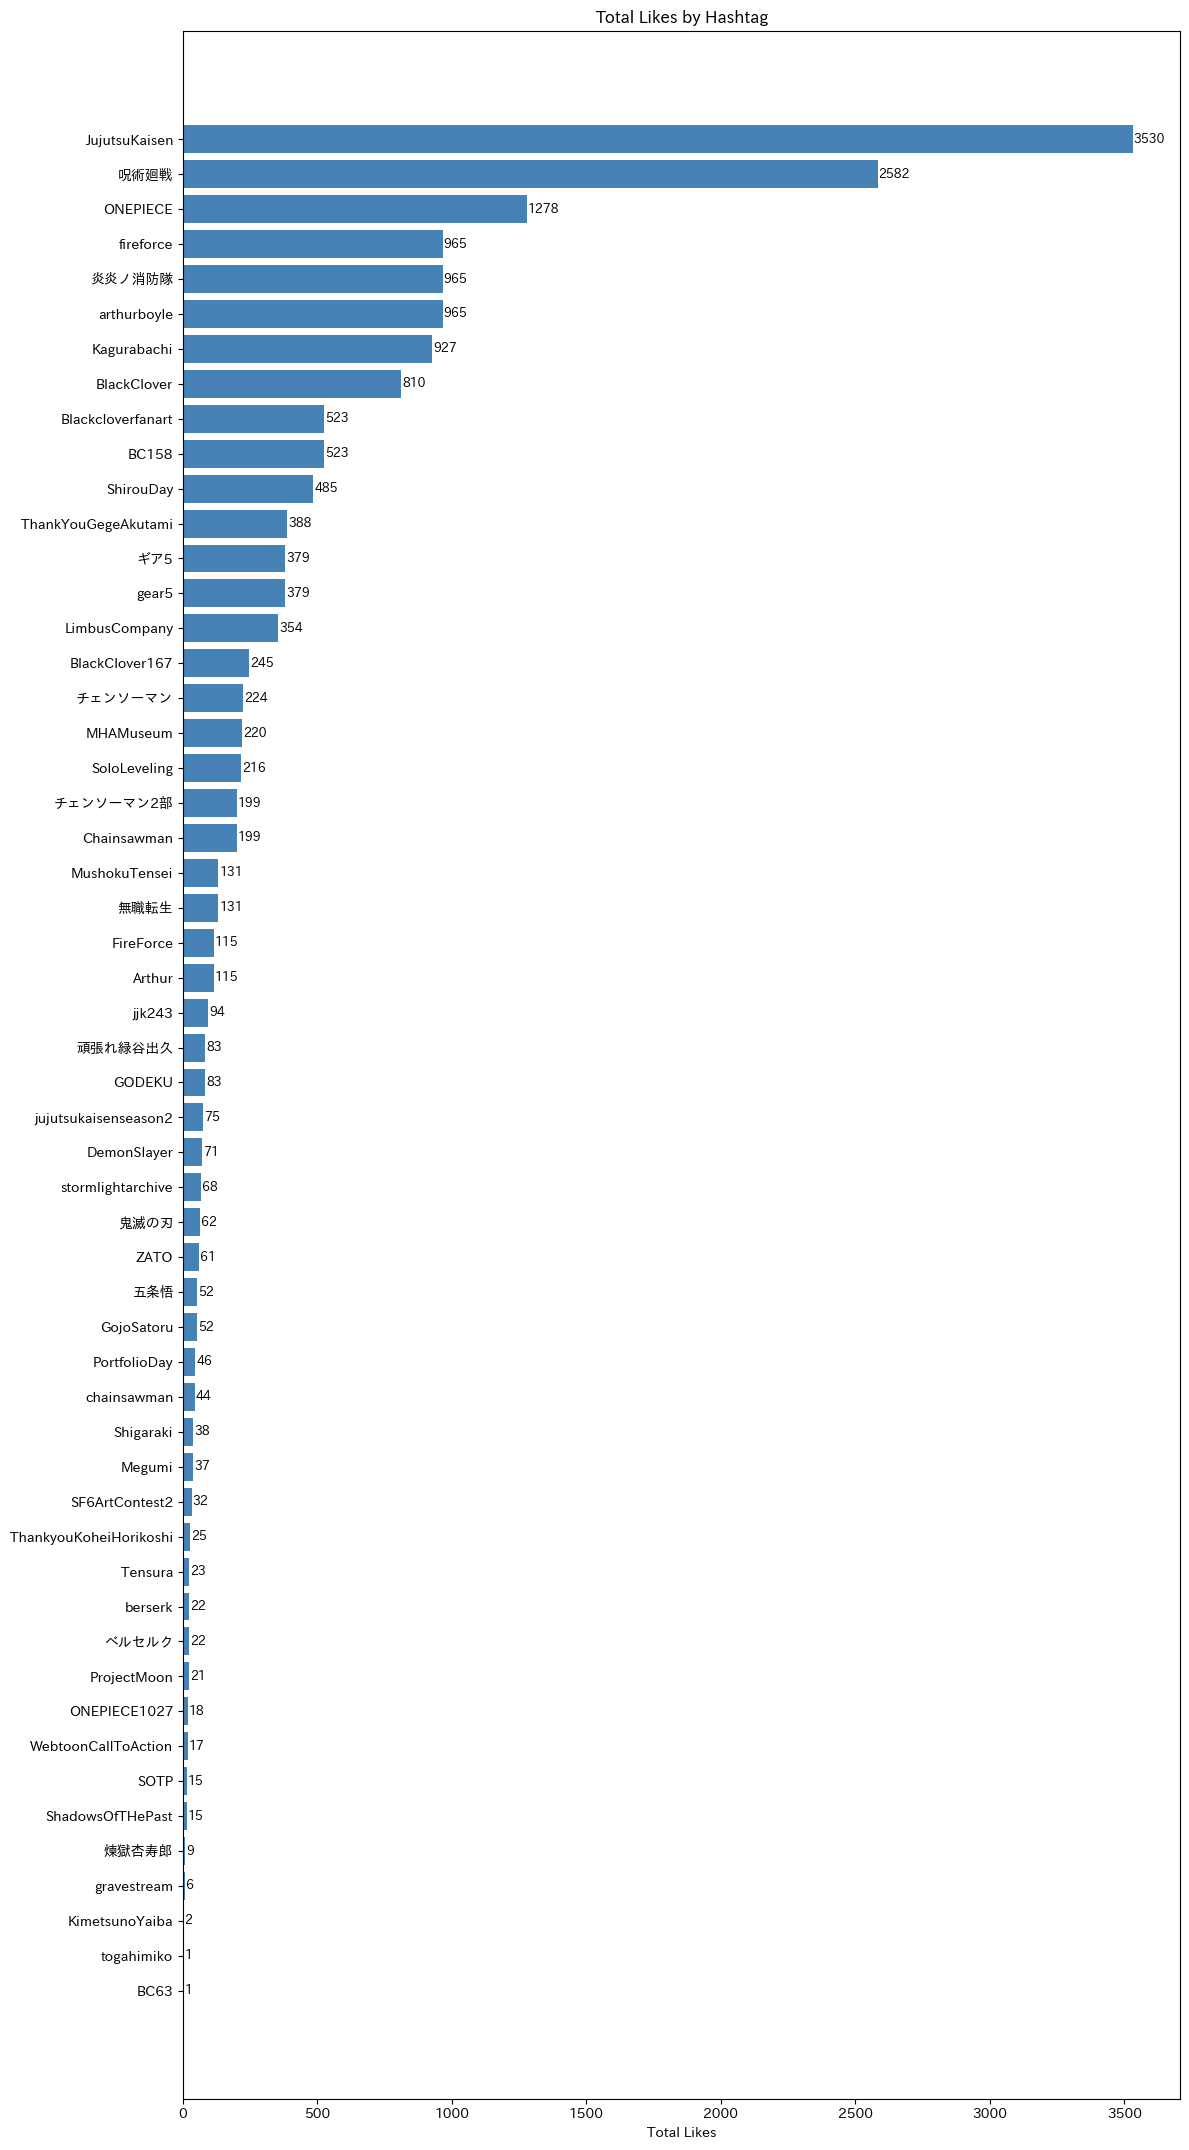

In [96]:
fig, ax = plt.subplots(figsize=(12, max(6, len(hashtag_totals) * 0.4)))

for i, val in enumerate(hashtag_totals.values):
    ax.text(val + 4, i, str(val), va='center', fontsize=9)

ax.barh(hashtag_totals.index, hashtag_totals.values, color='steelblue')
ax.set_xlabel('Total Likes')
ax.set_title('Total Likes by Hashtag')
plt.tight_layout()
plt.show()

Do note that the reason for the hashtags effect on the number of likes is likely due the popularity of the series referrenced at the time, meaning it would be dependant on how popular said series is at the time of posting. This is evidenced by the lower performance of non-popular/series based tags. One thing to maybe do in the future is compare performances with fanart, that are tagged and untagged. 


In [97]:
#Binning

tweets['Date'] = pd.to_datetime(tweets['Date'], utc=True)
tweets['Date'] = tweets['Date'].dt.tz_convert('America/New_York')
tweets['hour'] = tweets['Date'].dt.hour
tweets['day_of_week'] = tweets['Date'].dt.day_name()

def get_time_of_day(hour):
    if 5 <= hour < 12:    return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else:                 return 'Night'

tweets['time_of_day'] = tweets['hour'].apply(get_time_of_day)


In [98]:
#TOD vs Likes
print("Median likes by Time of Day:")
print(tweets.groupby('time_of_day')['Likes'].median().sort_values(ascending=False))

groups = [tweets[tweets['time_of_day'] == t]['Likes'].values
          for t in tweets['time_of_day'].unique()]
stat, p_val = stats.kruskal(*groups)

best_time = tweets.groupby('time_of_day')['Likes'].median().idxmax()
print(f"\nKruskal-Wallis p-value: {p_val:.5f}")
if p_val < 0.05:
    print("Result: statistically significant — time of day is associated with likes.")
    print(f'\nMost successful TOD: {best_time}')
else:
    print("Result: no statistically significant difference across times of day.")

Median likes by Time of Day:
time_of_day
Afternoon    18.0
Night        13.0
Evening       9.0
Morning       9.0
Name: Likes, dtype: float64

Kruskal-Wallis p-value: 0.00312
Result: statistically significant — time of day is associated with likes.

Most successful TOD: Afternoon


Note that before the timezone correction, it  listed evening as my most successful TOD. It is interesting how forgetting to take one thing into account can completely mess up the findings of this analysis.

In [99]:
#DOW vs Likes
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("\nMedian likes by Day of the Week:")
print(tweets.groupby('day_of_week')['Likes'].median().reindex(day_order))

day_groups = [tweets[tweets['day_of_week'] == d]['Likes'].values
              for d in day_order]
day_stat, day_p_val = stats.kruskal(*day_groups)
print(f"\nKruskal-Wallis p-value: {day_p_val:.5f}")
if day_p_val < 0.05:
    print("Result: statistically significant — day of week is associated with likes.")
else:
    print("Result: no statistically significant difference across days of week.")


Median likes by Day of the Week:
day_of_week
Monday        9.0
Tuesday      13.0
Wednesday    11.5
Thursday     15.0
Friday       11.0
Saturday     13.5
Sunday       13.0
Name: Likes, dtype: float64

Kruskal-Wallis p-value: 0.86064
Result: no statistically significant difference across days of week.


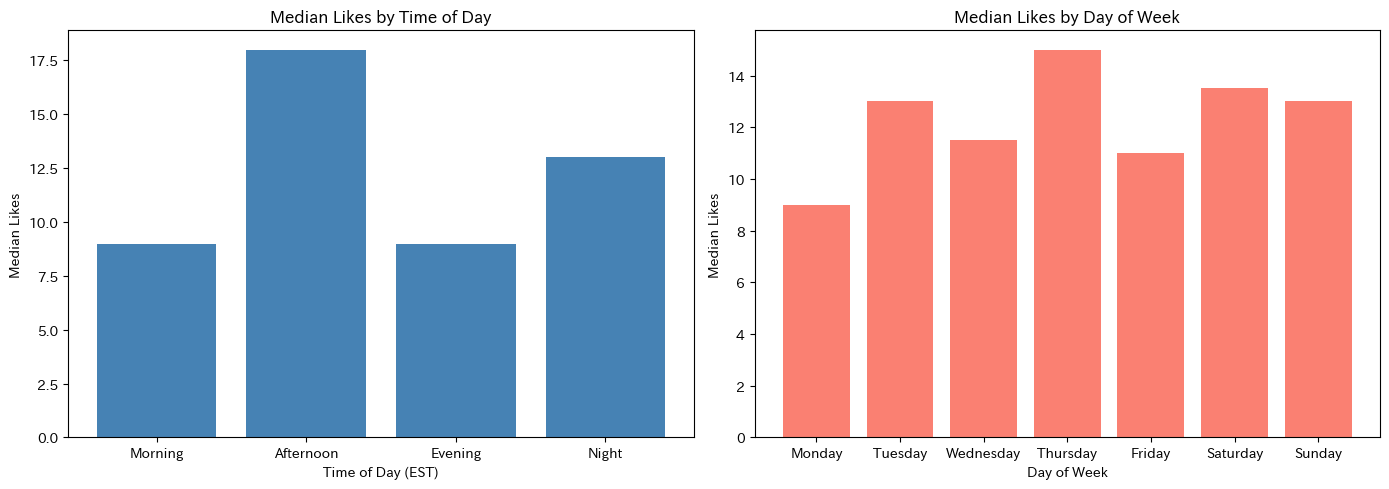

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Tod
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_perf = tweets.groupby('time_of_day')['Likes'].median().reindex(tod_order)
axes[0].bar(tod_perf.index, tod_perf.values, color='steelblue')
axes[0].set_xlabel('Time of Day (EST)')
axes[0].set_ylabel('Median Likes')
axes[0].set_title('Median Likes by Time of Day')

# Day of week
day_perf = tweets.groupby('day_of_week')['Likes'].median().reindex(day_order)
axes[1].bar(day_perf.index, day_perf.values, color='salmon')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Median Likes')
axes[1].set_title('Median Likes by Day of Week')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

Because three hypothesis tests were run on the same dataset, it increased the chance of a false positive each time. To account for this, the significance threshold is now p< 0.05/3 = 0.017 thanks to the "Beeferroni correction."
What this means: Time of day vs likes: p ≈ 0.014 — Barely passes (Interpret with Caution)


/var/folders/27/v4h_06ks6xncs2f8tkrzdvmr0000gn/T/ipykernel_1538/1762779819.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets['year_quarter'] = tweets['Date'].dt.to_period('Q').astype(str)


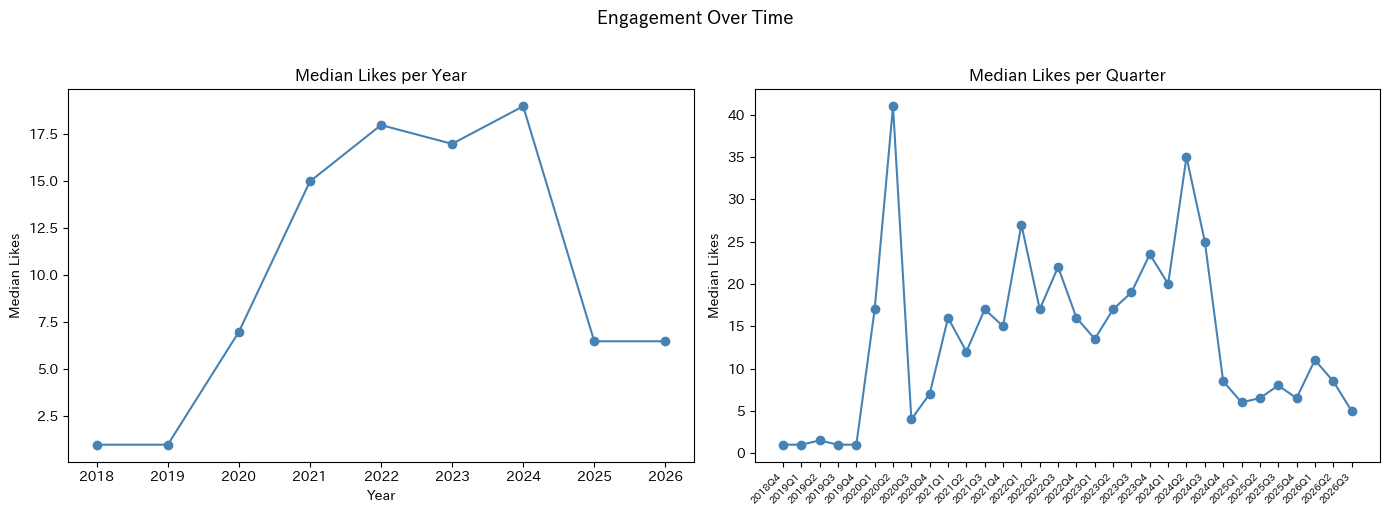

Median likes by year:
year
2018     1.0
2019     1.0
2020     7.0
2021    15.0
2022    18.0
2023    17.0
2024    19.0
2025     6.5
2026     6.5
Name: Likes, dtype: float64


In [107]:
# Median Likes over time
tweets['Date'] = pd.to_datetime(tweets['Date'], utc=True)
tweets['year'] = tweets['Date'].dt.year
tweets['year_quarter'] = tweets['Date'].dt.to_period('Q').astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Likes per year
year_perf = tweets.groupby('year')['Likes'].median()
axes[0].plot(year_perf.index, year_perf.values, marker='o', color='steelblue')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Likes')
axes[0].set_title('Median Likes per Year')
axes[0].set_xticks(year_perf.index)

# This year
quarter_perf = tweets.groupby('year_quarter')['Likes'].median()
axes[1].plot(range(len(quarter_perf)), quarter_perf.values, marker='o', color='steelblue')
axes[1].set_xticks(range(len(quarter_perf)))
axes[1].set_xticklabels(quarter_perf.index, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Median Likes')
axes[1].set_title('Median Likes per Quarter')

plt.suptitle('Engagement Over Time', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Median likes by year:")
print(year_perf)


Caption vs Likes & Retweets vs Likes aren't done, as through my personal observation's Captions can be random, as a lower-liked post can recieve more engagement in the form of comments due to the nature of the piece itself causing either discourse, or being circulated among friends (close friends whom the drawing was sent to/made for which is not something I can capture here). For retweets, the goal is to see what *makes* a post successsful, not markers of that success, which the number of retweets is.

**Quesstions**
1. Should I do Caption vs Likes, and/or Retweets vs. Likes? Despite my personal knowledge, would it not be best to still run them, and have "proof" of their redundancy? 
2. What else should I do/what can I do to improve this project? I don't plan on doing any form of regression (though I initially set out to) because the features won't be enough to accurately capture the target variable (Likes). 
3. Is there any way to simplify/remove clutter from the per quarter graph? It seems like trying to fit all that information requires some sacrifice of readability.
4. What are some basic things I can improve upon based on this project?